# Olist Weather-Delay Analysis — Exploratory Notebook

Companion analysis to the dbt/Snowflake pipeline in this repo. Pulls live data
directly from Snowflake and visualizes the correlation between severe weather
and late deliveries, plus the geocoding data-quality tradeoff documented in
the main README.

> **Note:** this notebook queries live data. Run it after `dbt run` has
> populated `fact_delivery_weather` and `geo_weather_station_bridge` for
> up-to-date results. Commit this notebook *with outputs saved* so charts
> render directly on GitHub without needing separate screenshots.


In [7]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from dotenv import load_dotenv
import snowflake.connector

load_dotenv()

conn = snowflake.connector.connect(
    account=os.environ["SNOWFLAKE_ACCOUNT"],
    user=os.environ["SNOWFLAKE_USER"],
    password=os.environ["SNOWFLAKE_PASSWORD"],
    warehouse=os.environ["SNOWFLAKE_WAREHOUSE"],
    database=os.environ["SNOWFLAKE_DATABASE"],
    schema=os.environ["SNOWFLAKE_SCHEMA"],
)

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False


## Load data

Pulls `fact_delivery_weather` and `geo_weather_station_bridge` directly from
the `RAW_analytics` / `RAW_transform` schemas.

In [8]:
fact = pd.read_sql(
    "SELECT * FROM RAW_analytics.fact_delivery_weather", conn
)
fact.columns = [c.lower() for c in fact.columns]

bridge = pd.read_sql(
    "SELECT * FROM RAW_transform.geo_weather_station_bridge", conn
)
bridge.columns = [c.lower() for c in bridge.columns]

fact["order_purchase_timestamp"] = pd.to_datetime(fact["order_purchase_timestamp"])
print(f"fact_delivery_weather: {len(fact):,} rows")
print(f"geo_weather_station_bridge: {len(bridge):,} rows")


C:\Users\Sunny\AppData\Local\Temp\ipykernel_19904\221287501.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  fact = pd.read_sql(
C:\Users\Sunny\AppData\Local\Temp\ipykernel_19904\221287501.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  bridge = pd.read_sql(


fact_delivery_weather: 99,441 rows
geo_weather_station_bridge: 19,015 rows


## Chart 1 — Late-delivery rate by severe weather

The core finding from the README: late-delivery rate compared for orders
with and without severe weather (precipitation > 20mm or wind > 40 km/h)
during the delivery window, at both destination and origin.

Rows with no weather match yet (`NULL`) are excluded from the rate
calculation but reported separately for transparency.

Destination: 278 orders excluded (no weather match yet)
Origin:      993 orders excluded (no weather match yet)


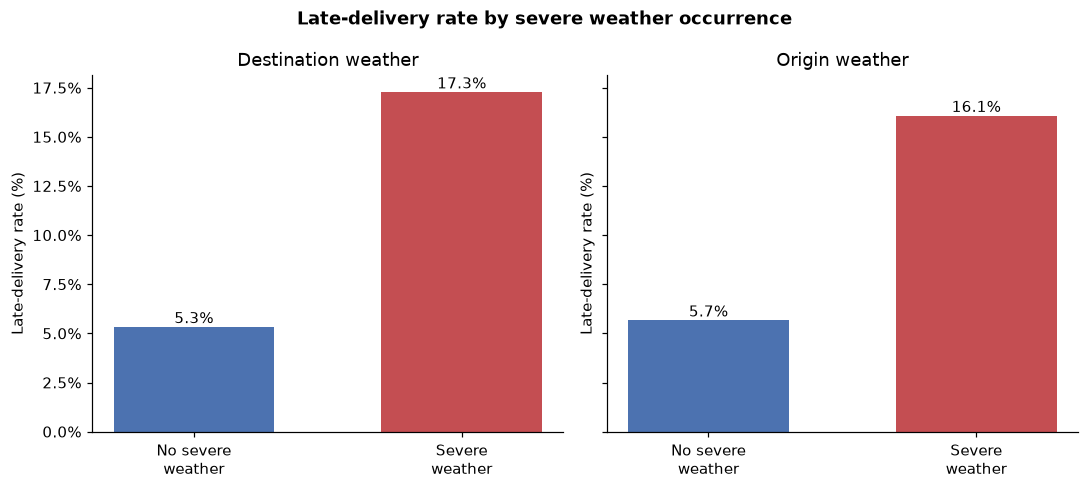

In [3]:
def late_rate_by_weather(df, weather_col):
    known = df[df[weather_col].notna()]
    null_count = df[weather_col].isna().sum()
    rates = known.groupby(weather_col)["is_late_delivery"].mean() * 100
    counts = known.groupby(weather_col).size()
    return rates, counts, null_count

dest_rates, dest_counts, dest_nulls = late_rate_by_weather(fact, "destination_had_severe_weather")
orig_rates, orig_counts, orig_nulls = late_rate_by_weather(fact, "origin_had_severe_weather")

print(f"Destination: {dest_nulls:,} orders excluded (no weather match yet)")
print(f"Origin:      {orig_nulls:,} orders excluded (no weather match yet)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)

for ax, rates, counts, title in [
    (axes[0], dest_rates, dest_counts, "Destination weather"),
    (axes[1], orig_rates, orig_counts, "Origin weather"),
]:
    labels = ["No severe\nweather", "Severe\nweather"]
    values = [rates.get(False, 0), rates.get(True, 0)]
    bars = ax.bar(labels, values, color=["#4C72B0", "#C44E52"], width=0.6)
    ax.set_title(title)
    ax.set_ylabel("Late-delivery rate (%)")
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    for bar, val in zip(bars, values):
        ax.annotate(f"{val:.1f}%", (bar.get_x() + bar.get_width() / 2, val),
                    ha="center", va="bottom", fontsize=10)

fig.suptitle("Late-delivery rate by severe weather occurrence", fontweight="bold")
plt.tight_layout()
plt.show()


**Reminder:** this is an observed association, not a causal claim — it
doesn't control for confounds like regional remoteness or seasonality (see
Chart 3 below, and the README for the full caveat).

## Chart 2 — Distance to nearest weather station

Visualizes the geocoding data-quality tradeoff: each zip-prefix centroid is
matched to the nearest ERA5 grid cell, with a 50km QC tolerance. This shows
how many centroids fall within vs. beyond that tolerance.

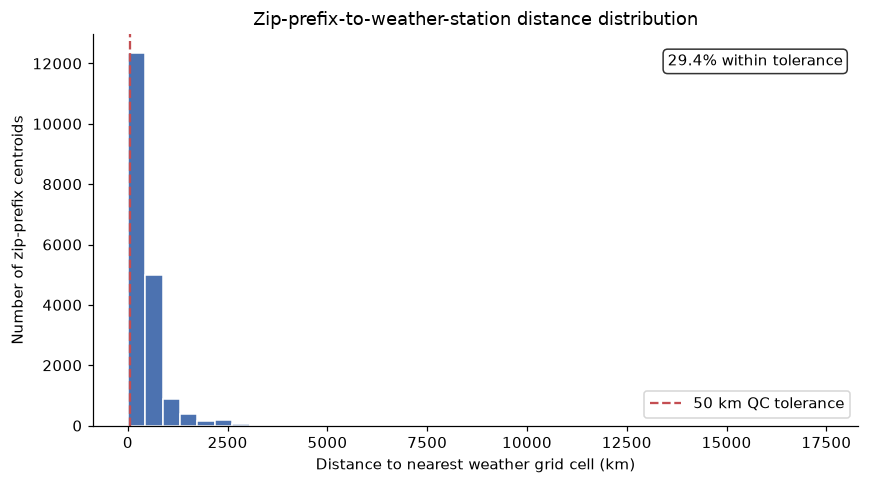

In [4]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(bridge["distance_km"], bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(50, color="#C44E52", linestyle="--", linewidth=1.5, label="50 km QC tolerance")
ax.set_xlabel("Distance to nearest weather grid cell (km)")
ax.set_ylabel("Number of zip-prefix centroids")
ax.set_title("Zip-prefix-to-weather-station distance distribution")
ax.legend()

pct_within = (bridge["distance_km"] <= 50).mean() * 100
ax.text(0.98, 0.95, f"{pct_within:.1f}% within tolerance",
        transform=ax.transAxes, ha="right", va="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
plt.tight_layout()
plt.show()


## Chart 3 — Order volume and late-delivery rate over time

Monthly view across the full 2016–2018 window. Useful for eyeballing
whether late-delivery spikes cluster around specific seasons — a real
confound this analysis doesn't formally control for (noted in the README).

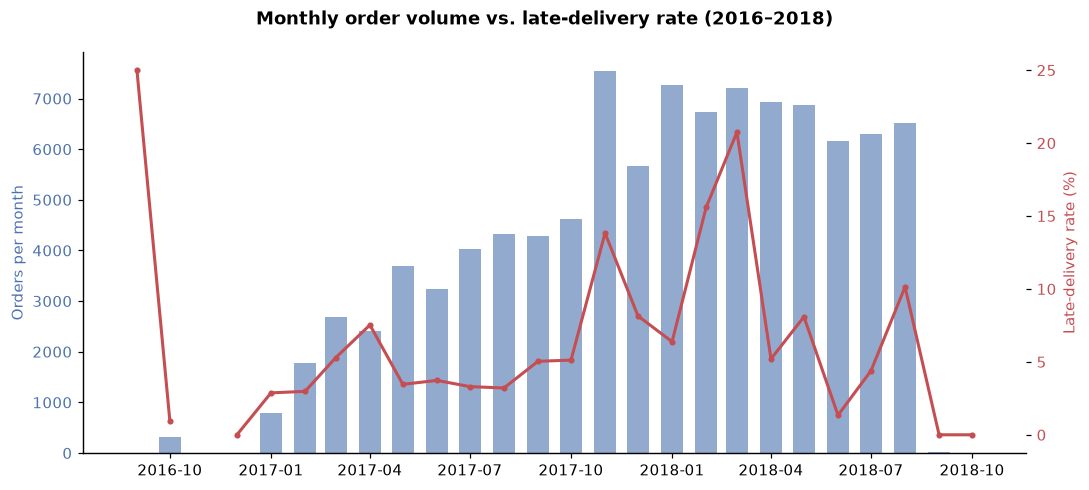

In [5]:
monthly = (
    fact.set_index("order_purchase_timestamp")
    .resample("MS")
    .agg(order_count=("order_id", "count"), late_rate=("is_late_delivery", "mean"))
)
monthly["late_rate"] *= 100

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(monthly.index, monthly["order_count"], width=20, color="#4C72B0", alpha=0.6, label="Order volume")
ax1.set_ylabel("Orders per month", color="#4C72B0")
ax1.tick_params(axis="y", labelcolor="#4C72B0")

ax2 = ax1.twinx()
ax2.plot(monthly.index, monthly["late_rate"], color="#C44E52", linewidth=2, marker="o", markersize=3, label="Late-delivery rate")
ax2.set_ylabel("Late-delivery rate (%)", color="#C44E52")
ax2.tick_params(axis="y", labelcolor="#C44E52")

fig.suptitle("Monthly order volume vs. late-delivery rate (2016–2018)", fontweight="bold")
fig.tight_layout()
plt.show()


## Summary

- Severe weather at either the delivery destination or shipping origin is
  associated with a meaningfully higher late-delivery rate than orders
  without severe weather during the delivery window.
- The effect size is similar at both ends of the journey, suggesting this
  isn't a purely last-mile phenomenon.
- This is a correlational finding. It does not control for regional
  remoteness or seasonality — both plausible confounds visible informally
  in Chart 3. A logistic regression controlling for shipping distance and
  month would be a natural next step to isolate weather's independent
  effect.
- See the main [README](../README.md) for the full pipeline architecture,
  data source notes, and known limitations.
